## Kendall's tau

Both `pv.Bicop` instances expose a `.tau` property; for the parametric Clayton it returns the analytic value $\theta / (\theta + 2)$, for `pv.tll` it returns a sample-based estimate from the fitted density.  `PFNRBicop.tau()` mirrors `pyvinecopulib`'s `KernelBicop::parameters_to_tau`: draw `n` quasi-random points via `pv.ghalton(n, 2)`, apply the inverse Rosenblatt transform along the first axis (using the inner regressor's `icdf`), then compute the weighted Kendall's $\tau$ on the resulting copula sample via `pv.wdm`.

## Setup

`PFNRBicop` wraps the local `tabpfn` package, which authenticates once via the `TABPFN_TOKEN` environment variable and then runs locally; no further cloud calls happen at inference time.  We pull the token from `.env` via `python-dotenv` (a dev-group dependency).

On CPU, TabPFN refuses to fit on more than 1000 samples by default.  Pass `model_kwargs={"ignore_pretraining_limits": True}` to `PFNRBicop` (or set the `TABPFN_ALLOW_CPU_LARGE_DATASET=1` environment variable) if you have a GPU and want to use a bigger sample.

In [4]:
from dotenv import load_dotenv

load_dotenv()  # populates TABPFN_TOKEN from .env

import matplotlib.pyplot as plt
import numpy as np
import pyvinecopulib as pv

from npcc import PFNRBicop

## Simulate from a Clayton copula and fit `PFNRBicop`

We pick $\theta = 3$ (strong positive lower-tail dependence), draw $n = 1000$ pseudo-observations (the CPU default cap), and fit `PFNRBicop` with its defaults (`symmetric=True`, `method="criterion"`).  The fit downloads the TabPFN-v2.5 regressor checkpoint on first call and caches it in the platform cache directory.

In [5]:
rho = 3.0
clayton = pv.Bicop(
  family=pv.BicopFamily.clayton,
  parameters=np.asarray([[rho]], dtype=np.float64),
)
u_train = clayton.simulate(n=1000, seeds=[2, 2, 4])

pfnr = PFNRBicop()
pfnr.fit(u_train[:, 0], u_train[:, 1])

## Quantitative comparison on a regular grid

We evaluate the fitted density on a $30 \times 30$ uniform grid, alongside the true Clayton density and `pv.tll` (a transformed local-likelihood benchmark) on the same grid.  Three error metrics:
$$
\mathrm{ISE} = \mathbb{E}\bigl[(\hat c - c)^2\bigr], \quad
\mathrm{IAE} = \mathbb{E}\bigl[|\hat c - c|\bigr], \quad
\mathrm{KL}  = \mathbb{E}\!\left[c (\log c - \log \hat c)\right].
$$
The `PFNRBicop` adapter from `as_bicop()` exposes the same `pdf(uv)` interface as a `pv.Bicop`, so the three estimators evaluate uniformly.  When the queried `uv` happens to span a Cartesian grid the adapter automatically reroutes through the fast `pdf_grid` path.

In [6]:
M = 30
u_axis = np.linspace(1 / M, 1 - 1 / M, M)
v_axis = np.linspace(1 / M, 1 - 1 / M, M)
U_mesh, V_mesh = np.meshgrid(u_axis, v_axis)
grid_uv = np.column_stack([U_mesh.flatten(), V_mesh.flatten()])

tll = pv.Bicop.from_data(u_train, pv.FitControlsBicop(family_set=[pv.tll]))

c_true = clayton.pdf(grid_uv)
c_tll = tll.pdf(grid_uv)
c_pfnr = pfnr.as_bicop().pdf(grid_uv)


def grid_metrics(
  c_true: np.ndarray, c_hat: np.ndarray, eps: float = 1e-12
) -> dict[str, float]:
  c_hat = np.maximum(c_hat, eps)
  c_true = np.maximum(c_true, eps)
  return {
    "ISE": float(np.mean((c_hat - c_true) ** 2)),
    "IAE": float(np.mean(np.abs(c_hat - c_true))),
    "KL": float(np.mean(c_true * (np.log(c_true) - np.log(c_hat)))),
  }


print("TLL  :", grid_metrics(c_true, c_tll))
print("PFNR :", grid_metrics(c_true, c_pfnr))

TLL  : {'ISE': 0.13400762953344209, 'IAE': 0.10812078964429196, 'KL': 0.017855115118899686}
PFNR : {'ISE': 0.016520648863565343, 'IAE': 0.07707488280135286, 'KL': 0.004056633790263526}


## Contour plots on standard-normal margins

All three estimators expose a `plot()` method that hands off to `pyvinecopulib`'s plotting helper.  For `PFNRBicop`, this goes through `as_bicop()` — the duck-typed adapter that exposes `var_types = ["c", "c"]` and `pdf(uv)`, exactly what `pyvinecopulib`'s plotter expects.  The Cartesian-grid fast path applies automatically.

Each call produces its own figure inline below.

True (Clayton, theta = 3.0)


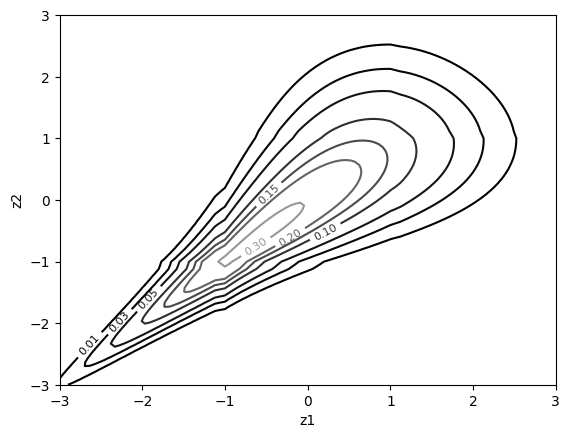

In [7]:
print("True (Clayton, theta = %.1f)" % rho)
clayton.plot(type="contour", margin_type="norm")

TLL benchmark


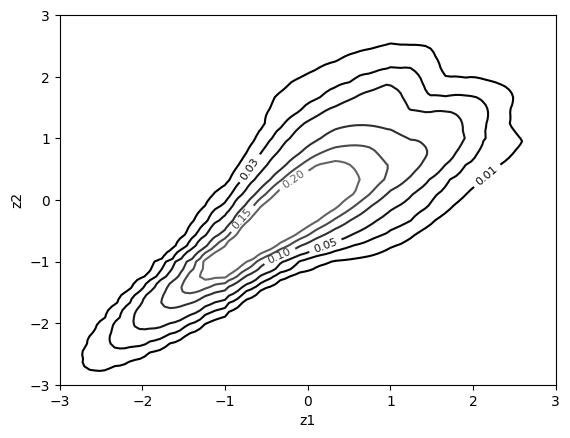

In [8]:
print("TLL benchmark")
tll.plot(type="contour", margin_type="norm")

PFNRBicop (criterion method, symmetric)


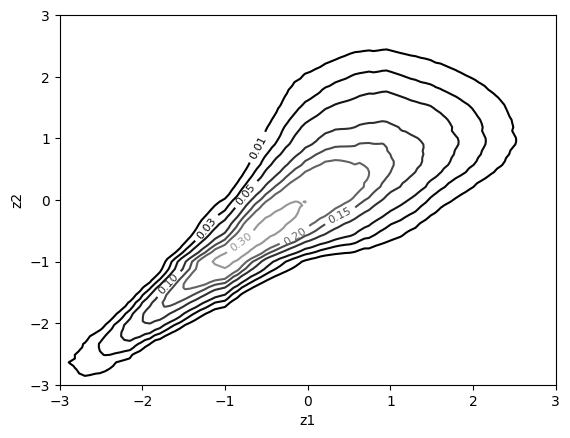

In [9]:
print("PFNRBicop (criterion method, symmetric)")
pfnr.plot(plot_type="contour", margin_type="norm")

## Kendall's tau

Both `pv.Bicop` instances expose a `.tau` property; for the parametric Clayton it returns the analytic value $\theta / (\theta + 2)$, for `pv.tll` it returns a sample-based estimate from the fitted density.  `PFNRBicop.tau()` mirrors `pyvinecopulib`'s `KernelBicop::parameters_to_tau`: draw `n` quasi-random points via `pv.ghalton(n, 2)`, apply the inverse Rosenblatt transform along the first axis (using the inner regressor's `icdf`), then compute the weighted Kendall's $\tau$ on the resulting copula sample via `pv.wdm`.

In [10]:
tau_pfnr = pfnr.tau(n=1000)

print(f"Clayton tau (analytic) : {clayton.tau:.4f}")
print(f"TLL tau                : {tll.tau:.4f}")
print(f"PFNRBicop tau (qmc)    : {tau_pfnr:.4f}")

Clayton tau (analytic) : 0.6000
TLL tau                : 0.5871
PFNRBicop tau (qmc)    : 0.6155


## h-function errors on the grid

h-functions are conditional CDFs — $h_1(u, v) = F_{U \mid V}(u \mid v) = \partial C / \partial v$, $h_2(u, v) = F_{V \mid U}(v \mid u) = \partial C / \partial u$.  They take values in $[0, 1]$, so we compare them via integrated squared and absolute errors only:
$$
\mathrm{ISE}_h = \mathbb{E}\bigl[(\hat h - h)^2\bigr], \quad
\mathrm{IAE}_h = \mathbb{E}\bigl[|\hat h - h|\bigr].
$$
`pv.Bicop.hfunc1` / `hfunc2` provide the truth and the `tll` benchmark; `PFNRBicop.hfunc1` / `hfunc2` are the direct conditional CDFs from the inner regressors (one batched call each, no integration).

In [11]:
h1_true = clayton.hfunc1(grid_uv)
h2_true = clayton.hfunc2(grid_uv)
h1_tll = tll.hfunc1(grid_uv)
h2_tll = tll.hfunc2(grid_uv)
h1_pfnr = pfnr.hfunc1(grid_uv[:, 0], grid_uv[:, 1])
h2_pfnr = pfnr.hfunc2(grid_uv[:, 0], grid_uv[:, 1])


def grid_h_metrics(h_true: np.ndarray, h_hat: np.ndarray) -> dict[str, float]:
  return {
    "ISE": float(np.mean((h_hat - h_true) ** 2)),
    "IAE": float(np.mean(np.abs(h_hat - h_true))),
  }


print("hfunc1 (TLL ) :", grid_h_metrics(h1_true, h1_tll))
print("hfunc1 (PFNR) :", grid_h_metrics(h1_true, h1_pfnr))
print("hfunc2 (TLL ) :", grid_h_metrics(h2_true, h2_tll))
print("hfunc2 (PFNR) :", grid_h_metrics(h2_true, h2_pfnr))

hfunc1 (TLL ) : {'ISE': 0.00032067363335572745, 'IAE': 0.011994421563663087}
hfunc1 (PFNR) : {'ISE': 0.000528668486307653, 'IAE': 0.01637388471011247}
hfunc2 (TLL ) : {'ISE': 0.00024406018756566584, 'IAE': 0.01109097885395648}
hfunc2 (PFNR) : {'ISE': 0.00028404712621817794, 'IAE': 0.011476616861399782}


## Joint CDF heatmap

The joint CDF on the $30 \times 30$ Cartesian grid is computed in a single batched call via `pfnr.cdf_grid(u_axis, v_axis)`.  Compare the visual shape against the true Clayton CDF.

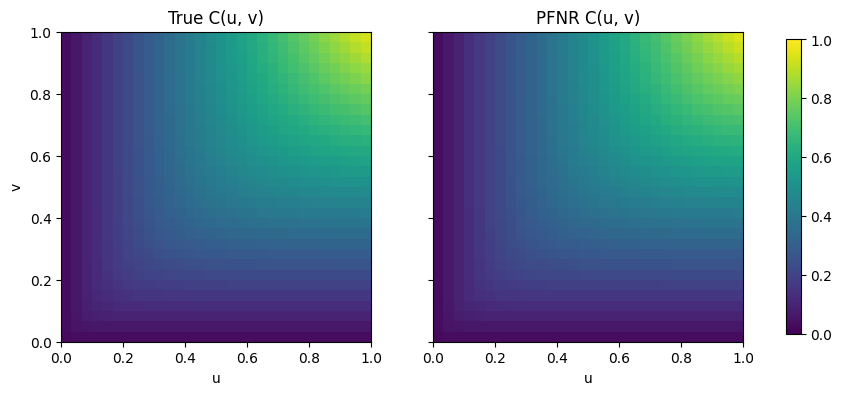

In [12]:
C_true = clayton.cdf(grid_uv).reshape(M, M)
C_pfnr = pfnr.cdf_grid(
  u_axis, v_axis, n_int=64
).T  # transpose to align with meshgrid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, data, title in [
  (axes[0], C_true, "True C(u, v)"),
  (axes[1], C_pfnr, "PFNR C(u, v)"),
]:
  im = ax.imshow(
    data,
    origin="lower",
    extent=(0.0, 1.0, 0.0, 1.0),
    aspect="equal",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
  )
  ax.set_title(title)
  ax.set_xlabel("u")
axes[0].set_ylabel("v")
fig.colorbar(im, ax=axes, shrink=0.85)
plt.show()